# Utility isolates informative augmentation from near-copying

Thin notebook for the two-spirals experiment. The implementation lives in `rankgen_utility_experiment/`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from rankgen_utility_experiment.experiment import ExperimentConfig, run_experiment, run_many, summarize, plot_spirals, plot_metric_bars, label_metric_columns

k = 4
include_noise_model = False

config = ExperimentConfig(
    seed=9,
    train_per_class=70,
    test_per_class=2_000,
    oracle_per_class=3_000,
    generated_per_class=1000,
    generator_latent_components=4,
    smote_neighbors=k,
    transfer_ab_neighbors=k,
    transfer_bc_neighbors=k,
    rf_n_estimators=50,
    rf_max_depth=None,
    rf_min_samples_leaf=4,
    rf_max_features="sqrt",
    rf_max_real_samples=2_000,
    rf_n_jobs=-1,
    turns=2.0,
    noise=0.085,
)
seeds = list(range(7, 12))

In [2]:
data, generated, one_run = run_experiment(
    config,
    include_noise_model=include_noise_model,
)
label_metric_columns(one_run).round(4)

,seed,generator,n_generated,quality ↑,utility_gain ↑,utility_augmented_accuracy ↑,baseline_accuracy ↑,similarity_to_train ↓,fid_to_oracle ↓,precision ↑,recall ↑,distinguishability_auc ↓
0,9,SMOTE interpolation,2000,0.9915,0.0245,0.9558,0.9312,0.0340,0.0007,0.9935,0.5548,0.8171
1,9,Transferred local differences,2000,0.9585,0.0282,0.9595,0.9312,0.0388,0.0001,0.9895,0.8183,0.6953


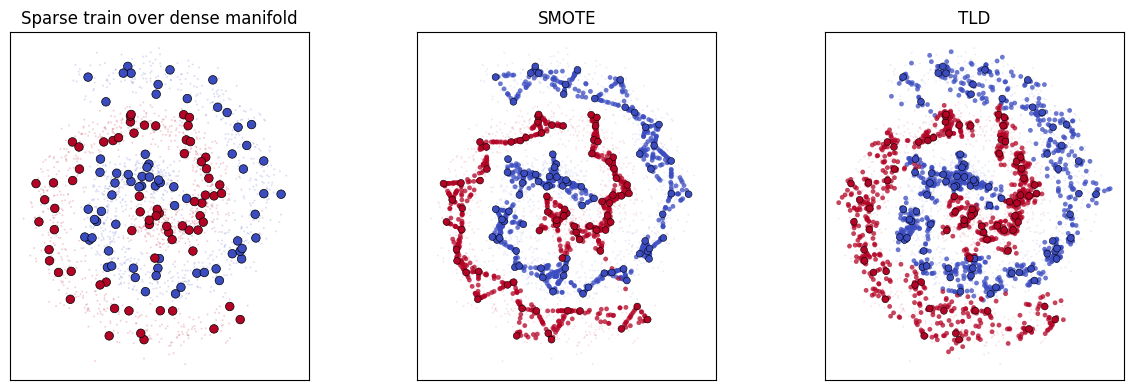

In [3]:
plot_spirals(data, generated);

In [4]:
results = run_many(
    seeds,
    config,
    include_noise_model=include_noise_model,
)
label_metric_columns(summarize(results)).round(4)

quality ↑         utility_gain ↑          \
                                   mean     std           mean     std   
generator                                                                
Transferred local differences    0.9631  0.0080         0.0271  0.0107   
SMOTE interpolation              0.9903  0.0041         0.0184  0.0086   

                              utility_augmented_accuracy ↑          \
                                                      mean     std   
generator                                                            
Transferred local differences                       0.9572  0.0041   
SMOTE interpolation                                 0.9484  0.0091   

                              baseline_accuracy ↑          \
                                             mean     std   
generator                                                   
Transferred local differences                0.93  0.0133   
SMOTE interpolation                          0.93  0.0133   

                              similarity_to_train ↓         fid_to_oracle ↓  \
                                               mean     std            mean   
generator                                                                     
Transferred local differences                0.0378  0.0008          0.0003   
SMOTE interpolation                          0.0331  0.0008          0.0006   

                                      precision ↑         recall ↑          \
                                  std        mean     std     mean     std   
generator                                                                    
Transferred local differences  0.0002      0.9905  0.0024   0.8070  0.0218   
SMOTE interpolation            0.0004      0.9938  0.0035   0.5484  0.0187   

                              distinguishability_auc ↓          
                                                  mean     std  
generator                                                       
Transferred local differences                   0.7154  0.0168  
SMOTE interpolation                             0.8238  0.0095

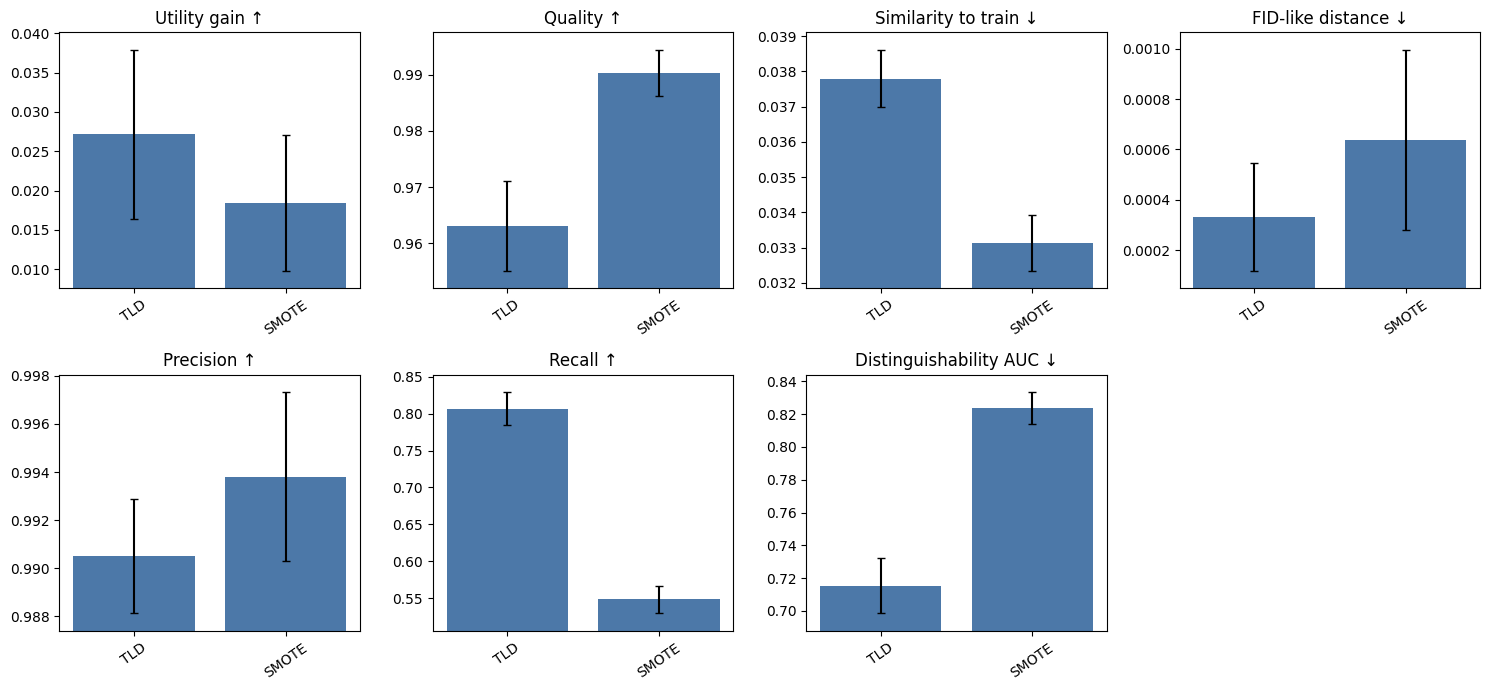

In [5]:
plot_metric_bars(results);